In [ ]:
# 1. Import and Load Dataset
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df=pd.read_csv("netflix_titles.csv")

print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

df.head()

Saving netflix_titles.csv to netflix_titles.csv
Dataset loaded successfully!
Rows and Columns: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# 2. Dataset Information

print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
# 3. Check Missing Values

missing = df.isnull().sum()

print("Missing Values:")
print(missing)

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [ ]:
# 4. Check Duplicate Values

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
# 5. Remove Duplicates

df = df.drop_duplicates()

print("Dataset after removing duplicates:", df.shape)

Dataset after removing duplicates: (8807, 12)


In [ ]:
# 6. Handle Missing Values

df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")

print("Missing values handled.")

Missing values handled.


In [ ]:
# 7. Convert Date Added to Date Format

df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

df["year_added"] = df["date_added"].dt.year

print(df[["date_added", "year_added"]].head())

  date_added  year_added
0 2021-09-25      2021.0
1 2021-09-24      2021.0
2 2021-09-24      2021.0
3 2021-09-24      2021.0
4 2021-09-24      2021.0


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


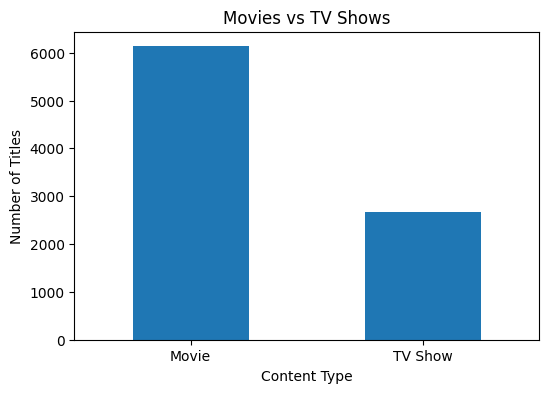

In [ ]:
# 8. Movies vs TV shows
type_count = df["type"].value_counts()

print(type_count)

plt.figure(figsize=(6,4))
type_count.plot(kind="bar")

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)

plt.show()

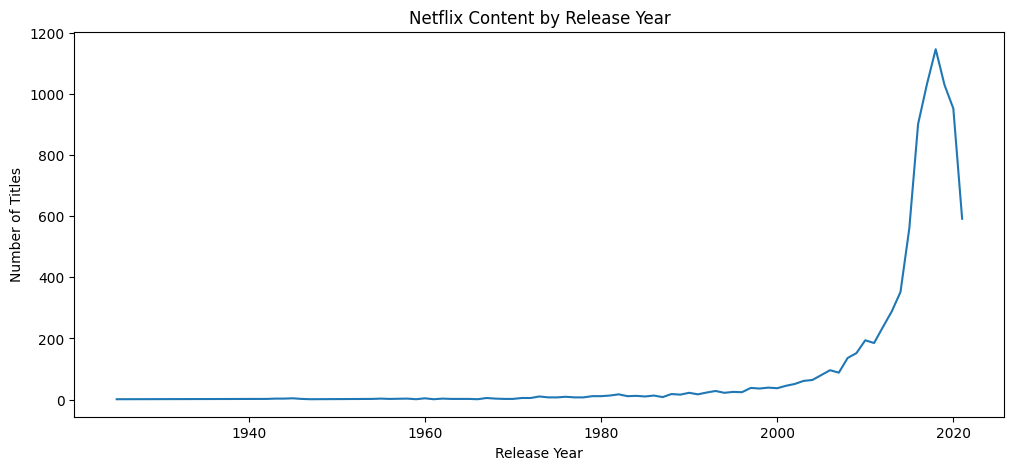

In [ ]:
#9. Content by Release year
year_count = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(year_count.index, year_count.values)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


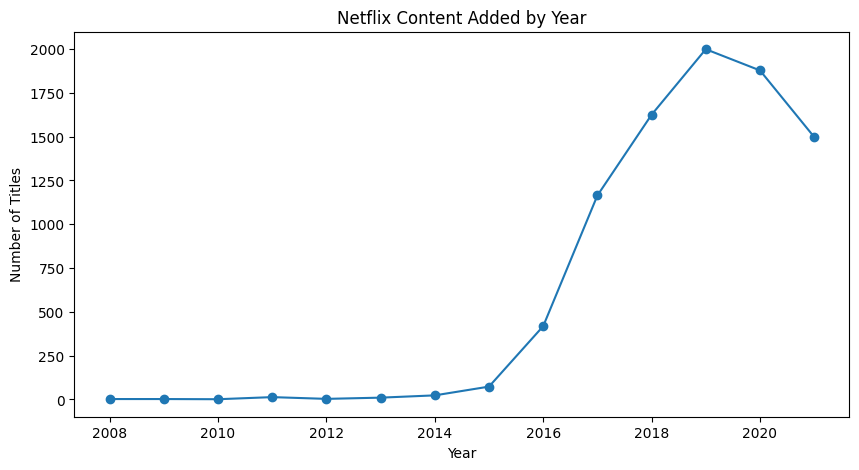

In [41]:
#10. Content Added by year
added_year = df["year_added"].value_counts().sort_index()

print(added_year)

plt.figure(figsize=(10,5))
plt.plot(added_year.index, added_year.values, marker="o")

plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


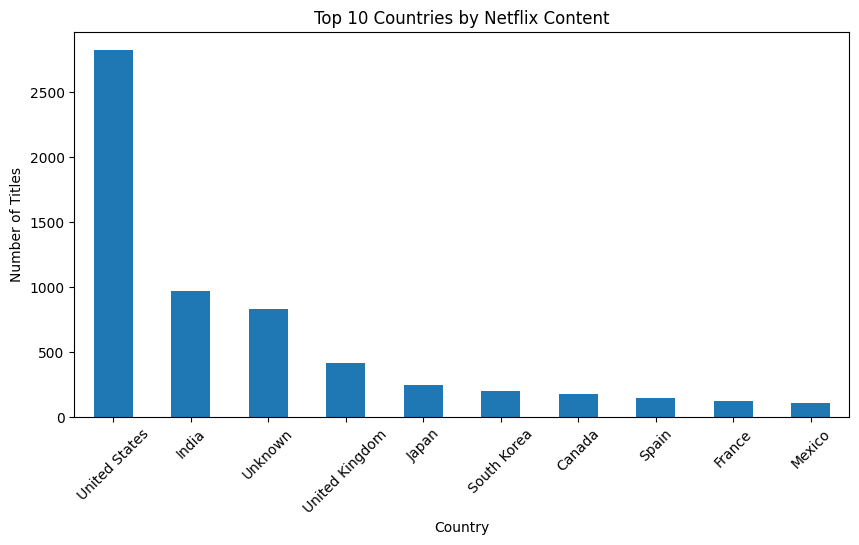

In [42]:
#11. Top 10 Countries
country_count = df["country"].value_counts().head(10)

print(country_count)

plt.figure(figsize=(10,5))
country_count.plot(kind="bar")

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


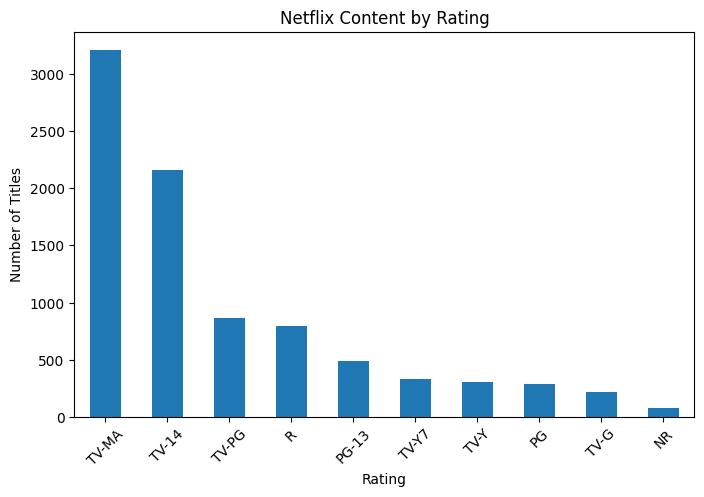

In [43]:
#12. Ratings Analysis
rating_count = df["rating"].value_counts().head(10)

print(rating_count)

plt.figure(figsize=(8,5))
rating_count.plot(kind="bar")

plt.title("Netflix Content by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

Top 10 Genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


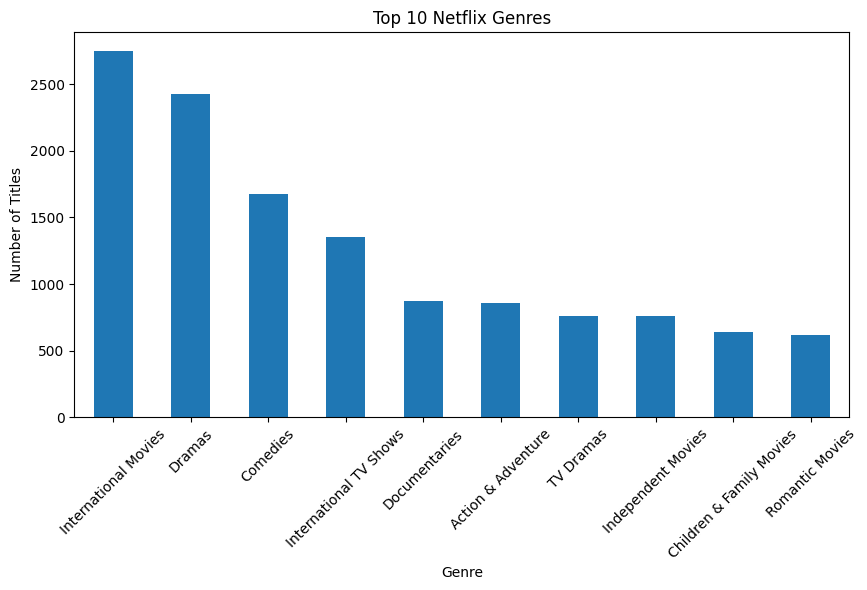

In [34]:
#13.Genre Analysis
genre_list = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
)

genre_count = genre_list.value_counts()

print("Top 10 Genres:")
print(genre_count.head(10))
plt.figure(figsize=(10,5))

genre_count.head(10).plot(kind="bar")

plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

Average Movie Duration: 99.57718668407311 minutes


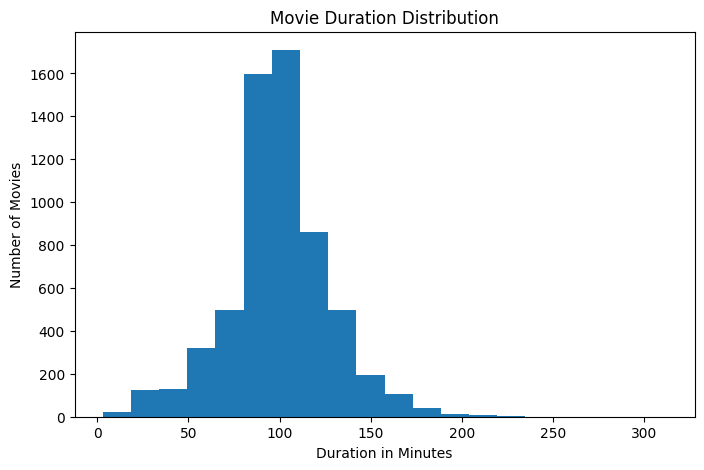

In [40]:
#14. Movie Duration
movies = df[df["type"] == "Movie"].copy()

movies["duration_minutes"] = (
    movies["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

print("Average Movie Duration:",
      movies["duration_minutes"].mean(),
      "minutes")
plt.figure(figsize=(8,5))

movies["duration_minutes"].plot(
    kind="hist",
    bins=20
)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration in Minutes")
plt.ylabel("Number of Movies")

plt.show()

In [39]:
#15. TV shows seasons
tv_shows = df[df["type"] == "TV Show"].copy()

tv_shows["seasons"] = (
    tv_shows["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

print(
    tv_shows[["title", "seasons"]]
    .sort_values("seasons", ascending=False)
    .head(10)
)

                       title  seasons
548           Grey's Anatomy     17.0
2423            Supernatural     15.0
4798                    NCIS     15.0
7847            Red vs. Blue     13.0
4220  COMEDIANS of the world     13.0
1354               Heartland     13.0
5412          Criminal Minds     12.0
4964       Trailer Park Boys     12.0
6456                  Cheers     11.0
6795                 Frasier     11.0


In [38]:
#16. Top Directors
directors = (
    df[df["director"] != "Unknown"]["director"]
    .value_counts()
    .head(10)
)

print("Top 10 Directors:")
print(directors)

Top 10 Directors:
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


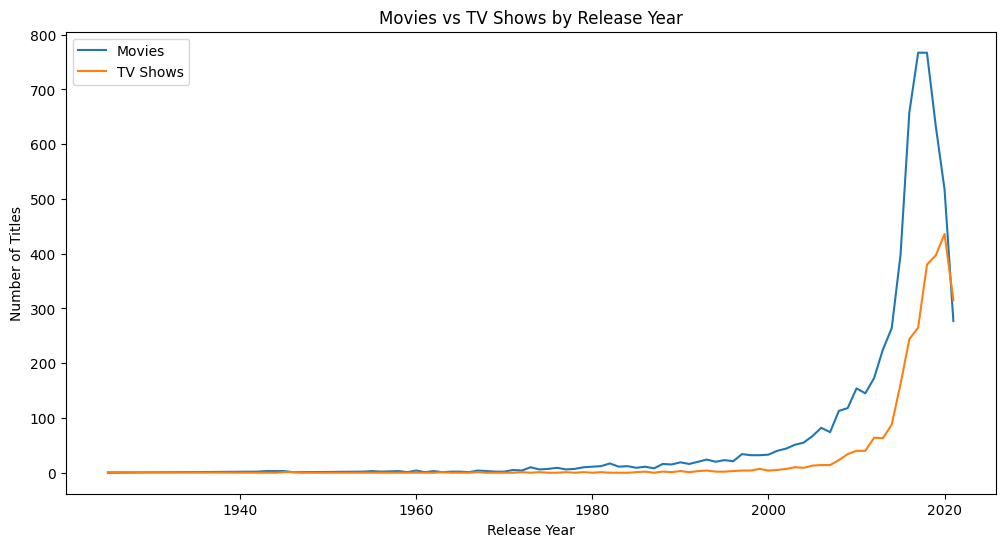

In [37]:
#17.Movies Vs TV shows by year
year_type = pd.crosstab(
    df["release_year"],
    df["type"]
)

plt.figure(figsize=(12,6))

plt.plot(
    year_type.index,
    year_type.get("Movie", 0),
    label="Movies"
)

plt.plot(
    year_type.index,
    year_type.get("TV Show", 0),
    label="TV Shows"
)

plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.show()

In [35]:
#18. Save cleaned dataset
df.to_csv("netflix_titles_cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
